# Busca Visual Semântica por Prompt com Gemma 4 (Museu Nacional)

Neste notebook:
1. Selecionamos **6 imagens de objetos totalmente distintos** da coleção `MN_003` (Maracá, Peneira, Abanador, Borduna, Crânio e Arco).
2. Geramos a descrição/análise visual de cada imagem com o **Gemma 4** (com cache para não reprocessar).
3. Você digita um **prompt de busca em linguagem natural** (ex: *"instrumento musical de cabaça usado em rituais"* ou *"arma indígena de madeira"*).
4. O Gemma 4 avalia a correspondência semântica e indica exatamente qual imagem melhor atende ao seu pedido, exibindo a imagem correspondente e a justificativa.

In [ ]:
import base64
import json
from pathlib import Path
import urllib.request
from IPython.display import display, Image, Markdown

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma4:latest"
IMG_DIR = Path("Base Museu Nacional/MN_003")

In [ ]:
def ask_gemma(prompt: str, image_path: Path = None, model: str = MODEL_NAME, num_predict: int = 4096) -> str:
    """Envia prompt e imagem (em base64) para a API HTTP do Ollama."""
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "num_predict": num_predict,
            "num_ctx": 16384
        }
    }
    if image_path and image_path.exists():
        with open(image_path, "rb") as f:
            payload["images"] = [base64.b64encode(f.read()).decode("utf-8")]
    
    req = urllib.request.Request(
        OLLAMA_URL,
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST"
    )
    with urllib.request.urlopen(req) as resp:
        res = json.loads(resp.read().decode("utf-8"))
        return res.get("response", "")

# Cache de representações visuais das imagens
if "image_representations" not in globals():
    image_representations = {}

In [2]:
# Seleção de 6 objetos claramente distintos da coleção MN_003
distinct_items = [
    {"file": "MN 003-33.jpg", "tipo": "Maracá (Instrumento musical / ritualístico)"},
    {"file": "MN 003-83.jpg", "tipo": "Peneira (Utilitário / trançado de taquara)"},
    {"file": "MN 003-88.jpg", "tipo": "Abanador (Fibras vegetais / conforto)"},
    {"file": "MN 003-93.jpg", "tipo": "Borduna (Arma contundente de madeira)"},
    {"file": "MN 003-1.jpg",  "tipo": "Crânio de Macaco (Osteológico / cura e proteção)"},
    {"file": "MN 003-98.jpg", "tipo": "Arco (Arma / madeira e corda)"},
]

print("Processando e indexando as 6 imagens com o Gemma 4...")
prompt_indexing = (
    "Analise esta imagem do acervo do Museu Nacional detalhadamente. "
    "Identifique o tipo de objeto, formato, materiais, detalhes visuais, cores, função e características que o definem."
)

for item in distinct_items:
    fname = item["file"]
    img_path = IMG_DIR / fname
    if fname not in image_representations:
        print(f"-> Analisando {fname} ({item['tipo']})...")
        image_representations[fname] = ask_gemma(prompt_indexing, img_path)
    else:
        print(f"-> [Cache] {fname} já indexado.")

print("\nTodas as 6 imagens foram indexadas com sucesso!")


Processando e indexando as 6 imagens com o Gemma 4...
-> Analisando MN 003-33.jpg (Maracá (Instrumento musical / ritualístico))...
-> Analisando MN 003-83.jpg (Peneira (Utilitário / trançado de taquara))...
-> Analisando MN 003-88.jpg (Abanador (Fibras vegetais / conforto))...
-> Analisando MN 003-93.jpg (Borduna (Arma contundente de madeira))...
-> Analisando MN 003-1.jpg (Crânio de Macaco (Osteológico / cura e proteção))...
-> Analisando MN 003-98.jpg (Arco (Arma / madeira e corda))...

Todas as 6 imagens foram indexadas com sucesso!


Buscando correspondência para o prompt: 'um objeto ritualístico feito de cabaça com fios e formato arredondado'...


### Consulta: *"um objeto ritualístico feito de cabaça com fios e formato arredondado"*



**IMAGEM SELECIONADA:** MN 003-33.jpg
**CONFIANÇA:** 85%
**JUSTIFICATIVA:** O objeto MN 003-33.jpg é o único que combina os três elementos cruciais da sua consulta: **função ritualística**, **formato arredondado/ovoide** e a presença de **fibras** ou fios. Embora a análise detalhada indique que o material é **madeira esculpida** e não cabaça, a descrição visual e a função são extremamente congruentes. O objeto possui um formato alongado e ovoidal ("gota d'água"), é explicitamente classificado como ritualístico, e apresenta um aglomerado proeminente de fios nas extremidades. É provável que o usuário tenha associado a materialidade e o aspecto orgânico da madeira com a cabaça.

**Segunda opção próxima:** MN 003-88.jpg
A segunda opção (MN 003-88.jpg) também é um objeto utilitário/ritualístico de formato arredondado e composto por fibras, mas é um cesto/recipiente trançado e o objeto em MN 003-33.jpg possui maior ênfase no aspecto ritualístico e no formato ovoidal fechado, aproximando-o mais da descrição de um objeto de "cabaça".

#### Imagem Encontrada: `MN 003-33.jpg` (Maracá (Instrumento musical / ritualístico))

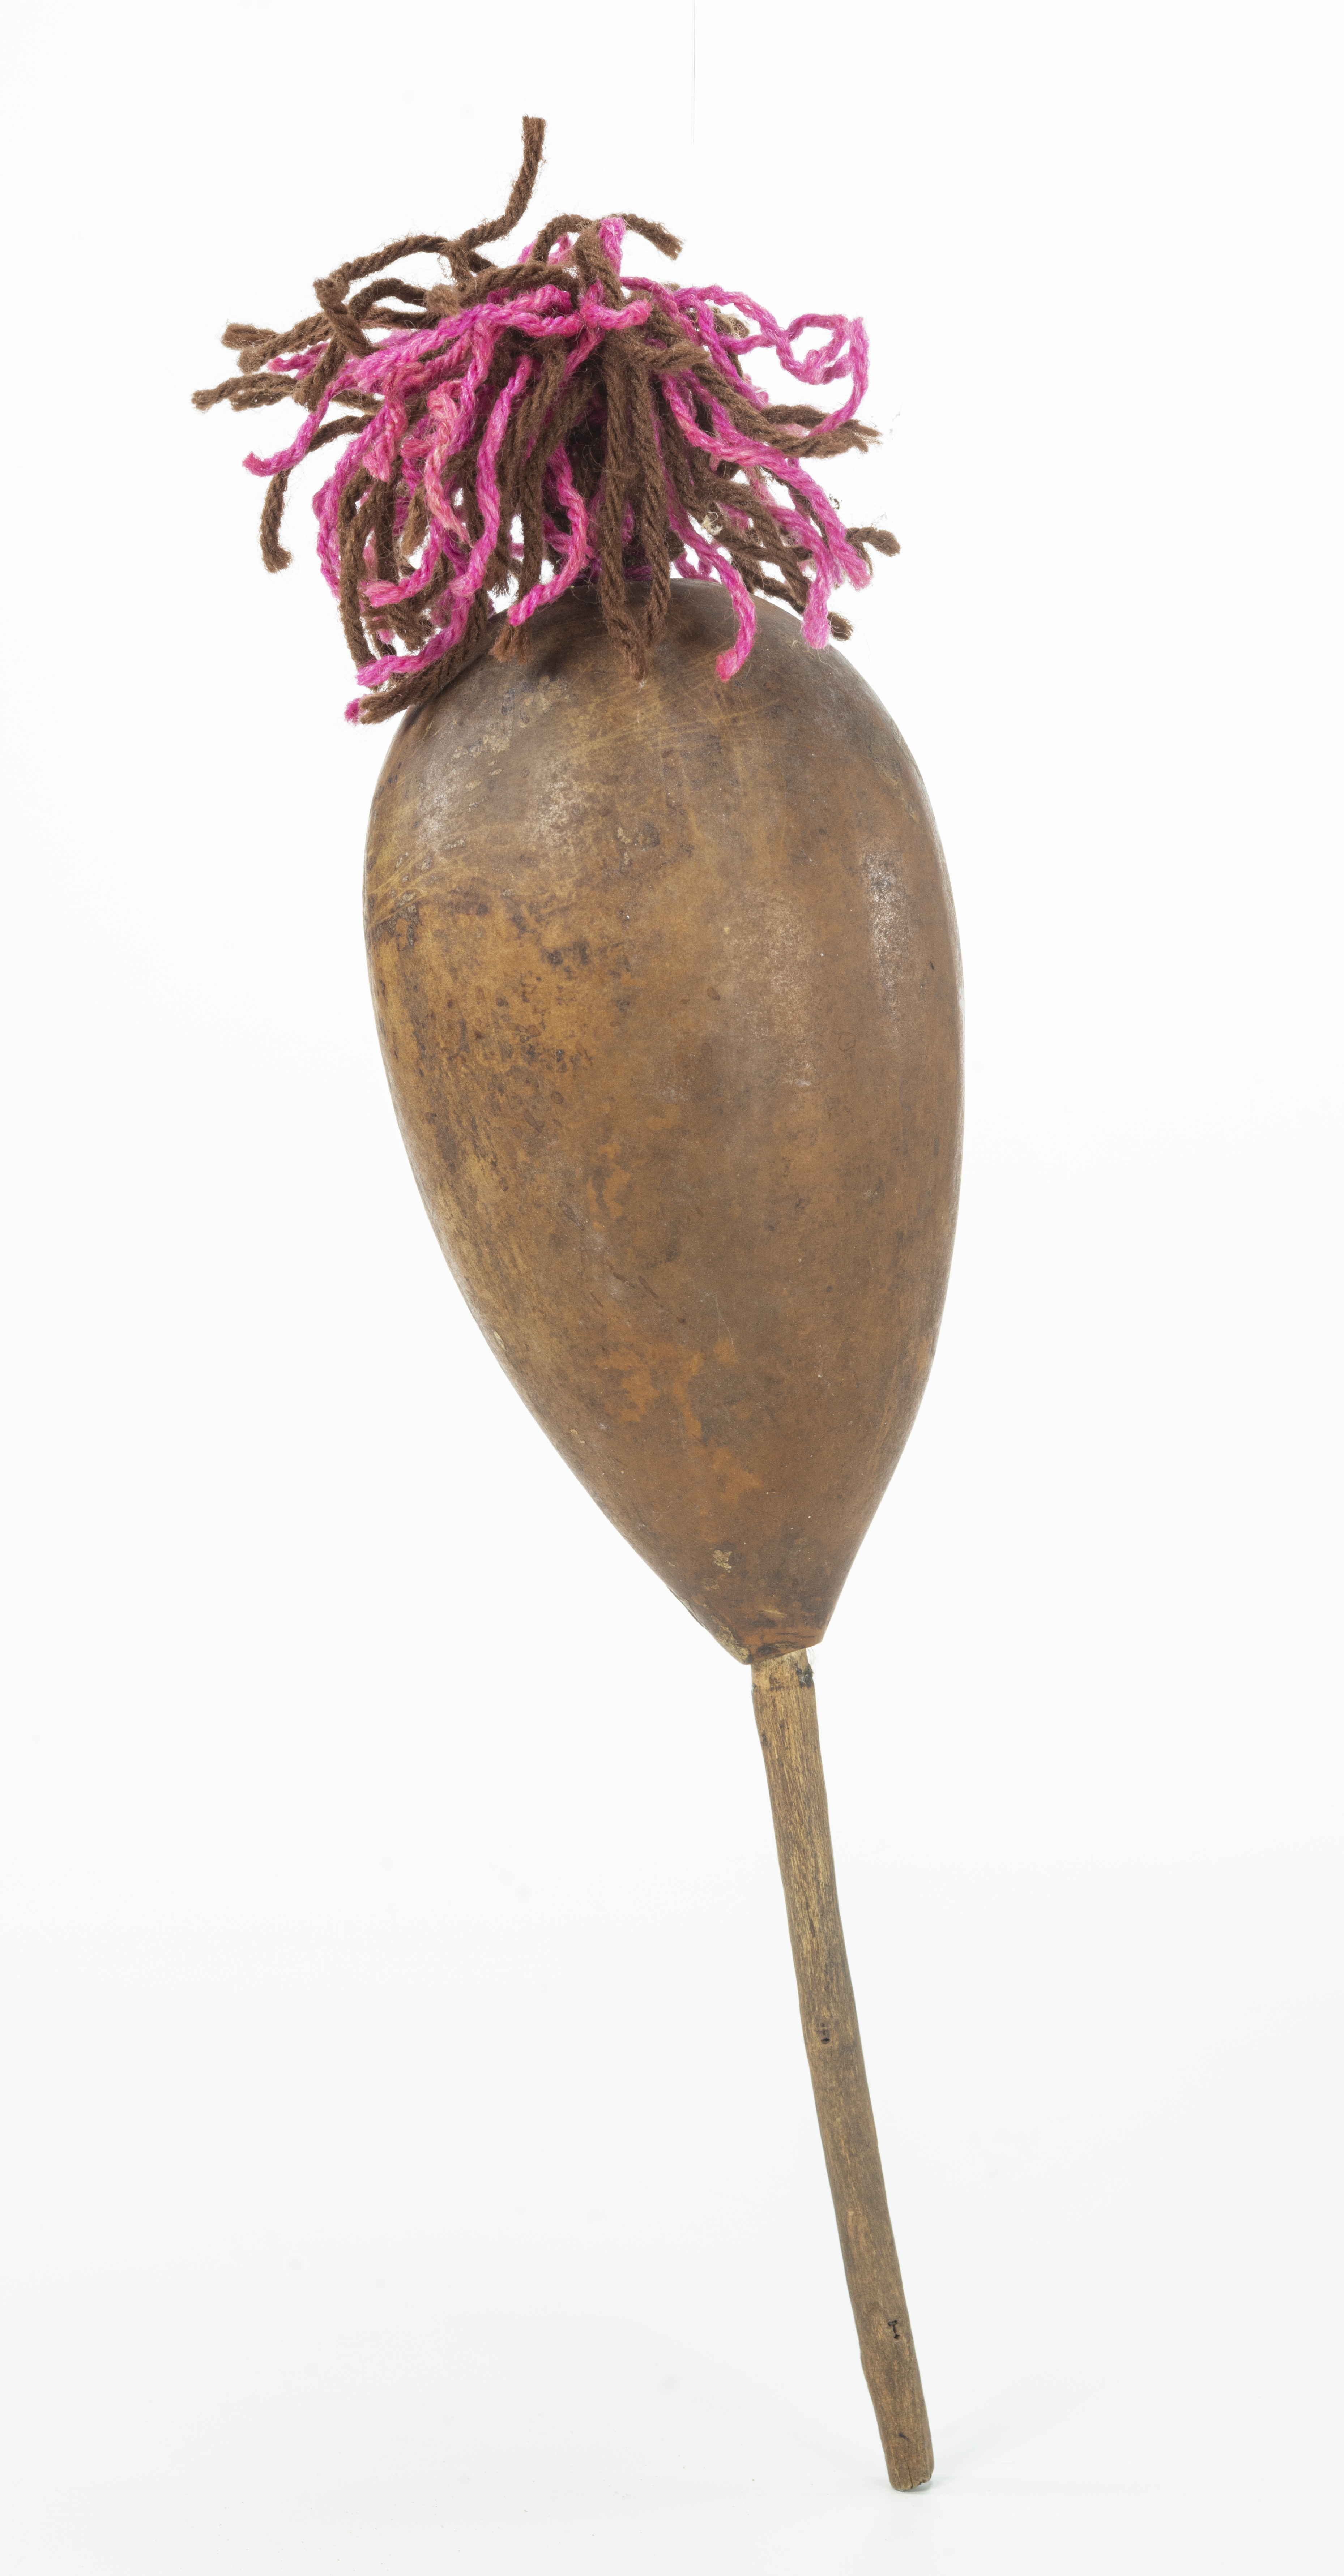

In [ ]:
# BUSCA POR PROMPT

prompt_busca = "um objeto ritualístico feito de cabaça com fios e formato arredondado"

# Monta o contexto para o Gemma 4 encontrar a correspondência semântica
contexto_imagens = "\n\n".join([
    f"ID: {item['file']}\nObjeto: {item['tipo']}\nCaracterísticas Visuais: {image_representations[item['file']]}"
    for item in distinct_items
])

prompt_matching = (
    f"Você é um assistente de busca multimodal para o acervo do Museu Nacional.\n\n"
    f"CONSULTA DO USUÁRIO:\n\"{prompt_busca}\"\n\n"
    f"CATÁLOGO DE IMAGENS DISPONÍVEIS:\n{contexto_imagens}\n\n"
    "INSTRUÇÕES:\n"
    "1. Indique qual imagem (especificando exatamente o ID do arquivo, ex: 'MN 003-XX.jpg') melhor corresponde à consulta.\n"
    "2. Dê uma nota de confiança de 0 a 100%.\n"
    "3. Justifique a correspondência explicando os elementos visuais e materiais que conectam a imagem ao prompt digitado.\n"
    "4. Se houver uma segunda opção próxima, mencione-a brevemente.\n\n"
    "Responda no formato:\n"
    "**IMAGEM SELECIONADA:** [nome_do_arquivo.jpg]\n"
    "**CONFIANÇA:** [X%]\n"
    "**JUSTIFICATIVA:** [sua explicação]"
)

print(f"Buscando correspondência para o prompt: '{prompt_busca}'...")
resposta_busca = ask_gemma(prompt_matching)

display(Markdown(f"### Consulta: *\"{prompt_busca}\"*\n\n"))
display(Markdown(resposta_busca))

# Localiza e exibe automaticamente a imagem escolhida na resposta
for item in distinct_items:
    fname = item["file"]
    if fname in resposta_busca:
        display(Markdown(f"#### Imagem Encontrada: `{fname}` ({item['tipo']})"))
        try:
            display(Image(filename=str(IMG_DIR / fname), width=380))
        except Exception:
            pass
        break
